# Módulo 1 — Riesgo de Crédito
## Notebook 2: Preprocesamiento de Datos

---

**Objetivo:**  
Transformar el dataset en bruto en un conjunto de datos limpio y listo para modelar.  
Este notebook cubre la traducción de códigos, la codificación de variables categóricas,  
la normalización de variables numéricas y el tratamiento del desbalance de clases mediante SMOTE.

**Input:** `datos/raw/german.data`  
**Output:** `datos/procesados/X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`

---

## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
columnas = [
    'estado_cuenta', 'duracion_meses', 'historial_credito', 'proposito',
    'importe', 'ahorro', 'empleo_actual', 'tasa_cuota',
    'estado_civil_sexo', 'otros_deudores', 'residencia_actual',
    'propiedad', 'edad', 'otros_planes', 'vivienda',
    'creditos_existentes', 'trabajo', 'personas_dependientes',
    'telefono', 'trabajador_extranjero', 'riesgo'
]

df = pd.read_csv('../../datos/raw/german.data', sep=' ', header=None, names=columnas)

# Variable objetivo: 0 = buen pagador, 1 = mal pagador
df['riesgo'] = df['riesgo'].map({1: 0, 2: 1})

print(f'✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')

✅ Dataset cargado: 1000 filas × 21 columnas


## 2. Traducción de códigos categóricos

Aplicamos el mapeo **antes** del One-Hot Encoding para que las columnas resultantes  
tengan nombres legibles en los gráficos de interpretabilidad (SHAP).

In [3]:
mapeo_estado_cuenta = {
    'A11': 'saldo_negativo',
    'A12': 'saldo_bajo',
    'A13': 'saldo_alto',
    'A14': 'sin_cuenta_corriente'
}
mapeo_historial = {
    'A30': 'sin_creditos_previos',
    'A31': 'todos_pagados_este_banco',
    'A32': 'creditos_al_dia',
    'A33': 'retrasos_en_pasado',
    'A34': 'cuenta_critica'
}
mapeo_proposito = {
    'A40': 'coche_nuevo',
    'A41': 'coche_usado',
    'A42': 'muebles',
    'A43': 'radio_tv',
    'A44': 'electrodomesticos',
    'A45': 'reparaciones',
    'A46': 'educacion',
    'A48': 'reciclaje_profesional',
    'A49': 'negocio',
    'A410': 'otros'
}
mapeo_ahorro = {
    'A61': 'ahorro_muy_bajo',
    'A62': 'ahorro_bajo',
    'A63': 'ahorro_medio',
    'A64': 'ahorro_alto',
    'A65': 'sin_ahorro'
}
mapeo_empleo = {
    'A71': 'desempleado',
    'A72': 'empleo_menos_1_anio',
    'A73': 'empleo_1_a_4_anios',
    'A74': 'empleo_4_a_7_anios',
    'A75': 'empleo_mas_7_anios'
}
mapeo_estado_civil = {
    'A91': 'hombre_divorciado',
    'A92': 'mujer_divorciada_casada',
    'A93': 'hombre_soltero',
    'A94': 'hombre_casado_viudo',
    'A95': 'mujer_soltera'
}
mapeo_otros_deudores = {
    'A101': 'ninguno',
    'A102': 'codeudor',
    'A103': 'avalista'
}
mapeo_propiedad = {
    'A121': 'inmueble',
    'A122': 'seguro_vida',
    'A123': 'coche_u_otro_bien',
    'A124': 'sin_propiedad'
}
mapeo_otros_planes = {
    'A141': 'plan_banco',
    'A142': 'plan_tienda',
    'A143': 'sin_otros_planes'
}
mapeo_vivienda = {
    'A151': 'alquiler',
    'A152': 'propiedad_propia',
    'A153': 'vivienda_gratuita'
}
mapeo_trabajo = {
    'A171': 'no_cualificado_no_residente',
    'A172': 'no_cualificado_residente',
    'A173': 'cualificado',
    'A174': 'directivo_autonomo'
}
mapeo_telefono = {
    'A191': 'sin_telefono',
    'A192': 'con_telefono'
}
mapeo_extranjero = {
    'A201': 'extranjero_si',
    'A202': 'extranjero_no'
}

df['estado_cuenta']     = df['estado_cuenta'].map(mapeo_estado_cuenta)
df['historial_credito'] = df['historial_credito'].map(mapeo_historial)
df['proposito']         = df['proposito'].map(mapeo_proposito)
df['ahorro']            = df['ahorro'].map(mapeo_ahorro)
df['empleo_actual']     = df['empleo_actual'].map(mapeo_empleo)
df['estado_civil_sexo'] = df['estado_civil_sexo'].map(mapeo_estado_civil)
df['otros_deudores']    = df['otros_deudores'].map(mapeo_otros_deudores)
df['propiedad']         = df['propiedad'].map(mapeo_propiedad)
df['otros_planes']      = df['otros_planes'].map(mapeo_otros_planes)
df['vivienda']          = df['vivienda'].map(mapeo_vivienda)
df['trabajo']           = df['trabajo'].map(mapeo_trabajo)
df['telefono']          = df['telefono'].map(mapeo_telefono)
df['trabajador_extranjero'] = df['trabajador_extranjero'].map(mapeo_extranjero)

print('✅ Códigos traducidos')
df[['estado_cuenta', 'historial_credito', 'empleo_actual']].head(5)

✅ Códigos traducidos


,estado_cuenta,historial_credito,empleo_actual
0,saldo_negativo,cuenta_critica,empleo_mas_7_anios
1,saldo_bajo,creditos_al_dia,empleo_1_a_4_anios
2,sin_cuenta_corriente,cuenta_critica,empleo_4_a_7_anios
3,saldo_negativo,creditos_al_dia,empleo_4_a_7_anios
4,saldo_negativo,retrasos_en_pasado,empleo_1_a_4_anios


## 3. Separación de variables

In [4]:
y = df['riesgo']

cols_numericas = ['duracion_meses', 'importe', 'tasa_cuota', 'residencia_actual',
                  'edad', 'creditos_existentes', 'personas_dependientes']

cols_categoricas = ['estado_cuenta', 'historial_credito', 'proposito', 'ahorro',
                    'empleo_actual', 'estado_civil_sexo', 'otros_deudores',
                    'propiedad', 'otros_planes', 'vivienda', 'trabajo',
                    'telefono', 'trabajador_extranjero']

print(f'Variables numéricas  : {len(cols_numericas)}')
print(f'Variables categóricas: {len(cols_categoricas)}')

Variables numéricas  : 7
Variables categóricas: 13


## 4. Codificación de variables categóricas (One-Hot Encoding)

Al haber traducido los códigos previamente, las columnas resultantes tendrán nombres legibles  
como `estado_cuenta_sin_cuenta_corriente` en lugar de `estado_cuenta_A14`.

In [5]:
df_cat_encoded = pd.get_dummies(df[cols_categoricas], drop_first=True)

print(f'Columnas tras el encoding: {df_cat_encoded.shape[1]}')
print('\nEjemplo de nombres de columnas:')
print(df_cat_encoded.columns.tolist()[:8])

Columnas tras el encoding: 41

Ejemplo de nombres de columnas:
['estado_cuenta_saldo_bajo', 'estado_cuenta_saldo_negativo', 'estado_cuenta_sin_cuenta_corriente', 'historial_credito_cuenta_critica', 'historial_credito_retrasos_en_pasado', 'historial_credito_sin_creditos_previos', 'historial_credito_todos_pagados_este_banco', 'proposito_coche_usado']


## 5. Normalización de variables numéricas

In [6]:
scaler = StandardScaler()
df_num_scaled = pd.DataFrame(
    scaler.fit_transform(df[cols_numericas]),
    columns=cols_numericas
)

print('Estadísticas tras la normalización (media ≈ 0, std ≈ 1):')
print(df_num_scaled.describe().loc[['mean', 'std']].round(2))

Estadísticas tras la normalización (media ≈ 0, std ≈ 1):
      duracion_meses  importe  tasa_cuota  residencia_actual  edad  \
mean             0.0      0.0         0.0               -0.0   0.0   
std              1.0      1.0         1.0                1.0   1.0   

      creditos_existentes  personas_dependientes  
mean                 -0.0                   -0.0  
std                   1.0                    1.0  


## 6. Construcción del dataset final

In [7]:
X = pd.concat([df_num_scaled.reset_index(drop=True),
               df_cat_encoded.reset_index(drop=True)], axis=1)

print(f'Dimensiones del dataset final: {X.shape[0]} filas × {X.shape[1]} columnas')
X.head(3)

Dimensiones del dataset final: 1000 filas × 48 columnas


,duracion_meses,importe,tasa_cuota,residencia_actual,edad,creditos_existentes,personas_dependientes,estado_cuenta_saldo_bajo,estado_cuenta_saldo_negativo,estado_cuenta_sin_cuenta_corriente,...,propiedad_sin_propiedad,otros_planes_plan_tienda,otros_planes_sin_otros_planes,vivienda_propiedad_propia,vivienda_vivienda_gratuita,trabajo_directivo_autonomo,trabajo_no_cualificado_no_residente,trabajo_no_cualificado_residente,telefono_sin_telefono,trabajador_extranjero_extranjero_si
0,-1.236478,-0.745131,0.918477,1.046987,2.766456,1.027079,-0.428290,False,True,False,...,False,False,True,True,False,False,False,False,False,True
1,2.248194,0.949817,-0.870183,-0.765977,-1.191404,-0.704926,-0.428290,True,False,False,...,False,False,True,True,False,False,False,False,True,True
2,-0.738668,-0.416562,-0.870183,0.140505,1.183312,-0.704926,2.334869,False,False,True,...,False,False,True,True,False,False,False,True,True,True


## 7. División train / test

> ⚠️ **Importante:** SMOTE solo se aplica sobre el conjunto de entrenamiento. Si lo aplicásemos sobre todo el dataset antes de dividir, estaríamos contaminando el test con datos sintéticos — un error frecuente que infla artificialmente las métricas.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'\nDistribución en train:')
print(y_train.value_counts().rename({0: 'Buen pagador', 1: 'Mal pagador'}))

Train: 800 muestras  |  Test: 200 muestras

Distribución en train:
riesgo
Buen pagador    560
Mal pagador     240
Name: count, dtype: int64


## 8. Tratamiento del desbalance de clases — SMOTE

Distribución ANTES de SMOTE:
riesgo
Buen pagador    560
Mal pagador     240
Name: count, dtype: int64

Distribución DESPUÉS de SMOTE:
riesgo
Mal pagador     560
Buen pagador    560
Name: count, dtype: int64


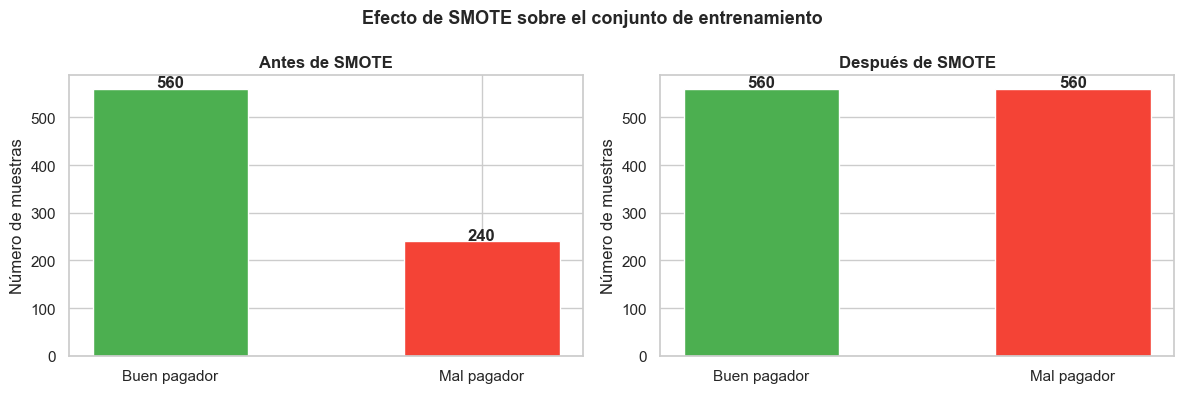

In [9]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Distribución ANTES de SMOTE:')
print(y_train.value_counts().rename({0: 'Buen pagador', 1: 'Mal pagador'}))
print(f'\nDistribución DESPUÉS de SMOTE:')
print(pd.Series(y_train_res).value_counts().rename({0: 'Buen pagador', 1: 'Mal pagador'}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, datos, titulo in zip(
    axes,
    [y_train, y_train_res],
    ['Antes de SMOTE', 'Después de SMOTE']
):
    conteo = pd.Series(datos).value_counts()
    ax.bar(['Buen pagador', 'Mal pagador'], [conteo[0], conteo[1]],
           color=['#4CAF50', '#F44336'], width=0.5)
    ax.set_title(titulo, fontweight='bold', fontsize=12)
    ax.set_ylabel('Número de muestras')
    for i, v in enumerate([conteo[0], conteo[1]]):
        ax.text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.suptitle('Efecto de SMOTE sobre el conjunto de entrenamiento', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Exportación del dataset procesado

In [10]:
X_train_res_df = pd.DataFrame(X_train_res, columns=X.columns)
X_test_df      = pd.DataFrame(X_test, columns=X.columns)

X_train_res_df.to_csv('../../datos/procesados/X_train.csv', index=False)
X_test_df.to_csv('../../datos/procesados/X_test.csv', index=False)
pd.Series(y_train_res).to_csv('../../datos/procesados/y_train.csv', index=False, header=True)
y_test.to_csv('../../datos/procesados/y_test.csv', index=False, header=True)

print('✅ Archivos exportados a datos/procesados/:')
print(f'   · X_train.csv  — {X_train_res_df.shape[0]} muestras × {X_train_res_df.shape[1]} columnas')
print(f'   · X_test.csv   — {X_test_df.shape[0]} muestras × {X_test_df.shape[1]} columnas')
print(f'   · y_train.csv')
print(f'   · y_test.csv')

✅ Archivos exportados a datos/procesados/:
   · X_train.csv  — 1120 muestras × 48 columnas
   · X_test.csv   — 200 muestras × 48 columnas
   · y_train.csv
   · y_test.csv


## 10. Resumen del preprocesamiento

---

| Paso | Técnica | Resultado |
|------|---------|----------|
| Traducción de códigos | Mapeo manual según documentación UCI | Variables legibles antes del encoding |
| Codificación categórica | One-Hot Encoding (`drop_first=True`) | 13 variables → ~40 columnas binarias |
| Normalización numérica | StandardScaler (media=0, std=1) | 7 variables normalizadas |
| División train/test | 80% / 20% estratificado | 800 train · 200 test |
| Balanceo de clases | SMOTE sobre train únicamente | Train equilibrado al 50/50 |

**💡 Nota metodológica:** Traducir los códigos antes del encoding es una buena práctica que mejora la trazabilidad del modelo — cualquier persona que revise los gráficos SHAP puede interpretar directamente qué variable está influyendo, sin necesidad de consultar la documentación del dataset.

